# Projekt 5: Uczenie przez wzmacnianie w przestrzeniach ciągłych

**Autorzy**: Kalina Rączka, Emilia Sarna

**Data**: 28.05.2026

### Charakterystyka wybranego środowiska

LunarLanderContinuous-v3 to środowisko z przestrzenią stanów ciągłych (8 cech: położenie landera, prędkości, kąt, prędkość kątowa oraz kontakty nóżek z podłożem) i akcjami ciągłymi (2 silniki w zakresie [-1, 1]).

Nagroda ma charakter pomocniczy i etapowy (reward shaping) i zależy m.in. od stabilności lotu, bliskości platformy oraz bezpiecznego lądowania. Epizod kończy się po wylądowaniu, rozbiciu lub opuszczeniu obszaru.

### Charakterystyka algortymu

Zostały zastosowane dwa algorytmy z biblioteki stable-baselines3 przystosowane do sterowania w przestrzeniach ciągłych: 
- PPO (on-policy) - PPO uczy się wyłącznie na danych, które sam przed chwilą zebrał, używając swojej najnowszej strategii (polityki). Gdy zaktualizuje wagę sieci neuronowej, stare dane zostają odrzucane, a agent musi zebrać nowe doświadczenia. Posiada specjalną funkcję celu, która ogranicza krok nauki. Dzięki temu nowa strategia nie różni się drastycznie od starej, co zapobiega nagłemu "rozsypaniu się" modelu podczas treningu.
- SAC (entropy + off-policy) - Jako algorytm off-policy, SAC zapisuje wszystkie swoje historyczne próby (udane i nieudane) do tzw. Replay Buffer (pamięci powtórek) i losuje z niej próbki do nauki. Dodatkowo, SAC jest nagradzany za bycie losowym (wysoka entropia). Agent stara się wykonać zadanie, ale w taki sposób, by zachować jak najwięcej alternatywnych ścieżek ruchu.

### Wybrane hiperparametry

Dla każdego algorytmu przygotowano trzy zestawy hiperparametrów. Każdy zestaw uruchamiany jest 10 razy.

Poniżej przedstawiono zestawy hiperparametrów dla poszczególnych procesów uczenia oraz czas potrzebny na naukowę jednego kroku czasowego oraz epizodu.

In [1]:
from pathlib import Path
import json

RESULTS_DIR = Path("results")

def _fmt(value, ndigits=3):
    if value is None:
        return "n/a"
    return f"{value:.{ndigits}f}"

def load_config_rows():
    rows = []
    for summary_path in RESULTS_DIR.rglob("summary.json"):
        algo = summary_path.parent.parent.name
        if algo == "TD3":
            continue
        config = summary_path.parent.name
        with open(summary_path, "r", encoding="utf-8") as file:
            summary = json.load(file)
        params_path = summary_path.parent / "params.json"
        params = {}
        if params_path.exists():
            with open(params_path, "r", encoding="utf-8") as file:
                params = json.load(file)
        rows.append(
            {
                "algo": algo,
                "config": config,
                "mean_reward": summary.get("mean_reward"),
                "std_reward": summary.get("std_reward"),
                "mean_last_25%": summary.get("mean_last_25%"),
                "time_step": summary.get("avg_time_per_timestep_sec"),
                "time_episode": summary.get("avg_time_per_episode_sec"),
                "params": params.get("params", {}),
            }
        )
    return rows

rows = load_config_rows()
for row in sorted(rows, key=lambda r: (r["algo"], r["config"])):
    print(
        f"{row['algo']:>3} | {row['config']:<8} | "
        f"mean={_fmt(row['mean_reward'], 1)} +/- {_fmt(row['std_reward'], 1)} | "
        f"last25={_fmt(row['mean_last_25%'], 1)}"
    )
    print(
        f"    time_step={_fmt(row['time_step'], 6)}s, "
        f"time_episode={_fmt(row['time_episode'], 4)}s"
    )
    print(f"    params={row['params']}")
    print("")


PPO | ppo_a    | mean=-9.2 +/- 133.5 | last25=-9.9
    time_step=0.000203s, time_episode=0.1207s
    params={'learning_rate': 0.0003, 'gamma': 0.99, 'gae_lambda': 0.95, 'batch_size': 256, 'n_steps': 2048, 'ent_coef': 0.0}

PPO | ppo_b    | mean=-103.7 +/- 106.5 | last25=-78.6
    time_step=0.000182s, time_episode=0.1131s
    params={'learning_rate': 0.001, 'gamma': 0.98, 'gae_lambda': 0.9, 'batch_size': 512, 'n_steps': 2048, 'ent_coef': 0.01}

PPO | ppo_c    | mean=-25.6 +/- 136.7 | last25=-12.2
    time_step=0.000206s, time_episode=0.0968s
    params={'learning_rate': 0.0001, 'gamma': 0.995, 'gae_lambda': 0.98, 'batch_size': 256, 'n_steps': 4096, 'ent_coef': 0.0}

SAC | large    | mean=125.2 +/- 173.1 | last25=85.7
    time_step=0.006891s, time_episode=3.5013s
    params={'learning_rate': 0.0003, 'gamma': 0.99, 'tau': 0.005, 'batch_size': 256, 'buffer_size': 300000, 'train_freq': 1, 'gradient_steps': 1}

SAC | sac_a    | mean=-83.9 +/- 145.8 | last25=-94.1
    time_step=0.002505s, tim

Dla wszystkich algorytmów zmieniano learning rate, batch size. Dodatkowo dla PPO zmieniano gammę, gae lambdę oraz liczbę kroków, dla SAC gammę oraz tau.

### Krzywe uczenia

Wyniki uczenia każdego z algorytmów zostały przedstawione poprzez krzywą uczenia średniej nagrody (reward) w zależności od kroków czasowych (timesteps). Na wykresach zaznaczono też próg sukcesu oraz odchylenie standardowe.

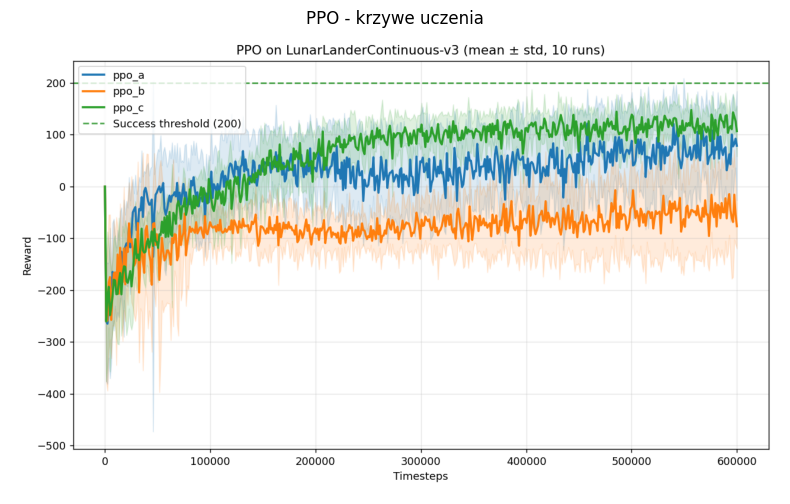

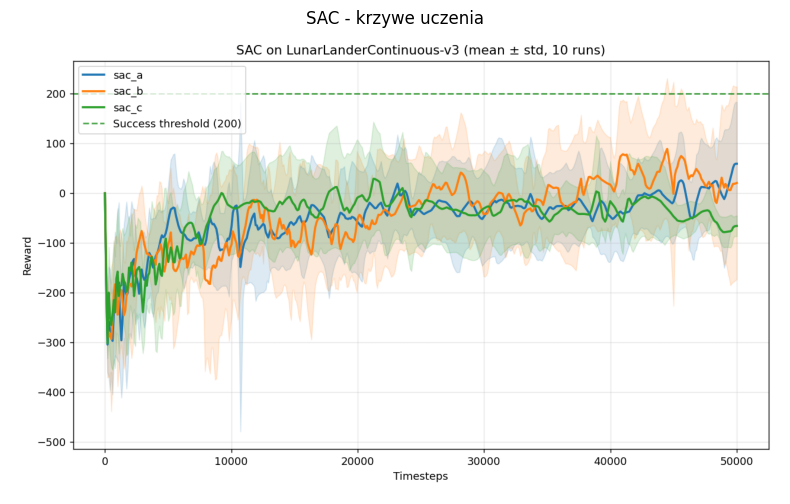

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for algo in ["PPO", "SAC"]:
    curve_path = RESULTS_DIR / algo / "comparison_curve.png"
    if not curve_path.exists():
        print(f"Brak wykresu dla {algo}: {curve_path}")
        continue
    img = mpimg.imread(curve_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{algo} - krzywe uczenia")
    plt.show()

### Opis wyników

- PPO

Krzywa uczenia wskazuje na stopniową naukę w czasie (600 000 kroków). Model b nauczył się zdecydowanie najgorzej. Jego krzywa czenia jest najbardziej płaska ze wszystkich - przestał się uczyć na etapie ok. 100 tys. kroków oraz najniższa pod względem uzyskanej nagrody (maksymalnie w okolicach -50). Może to wynikać z najwyższego learning rate (0.001). Lepiej sobie poradziły a i c, które regularnie zdobywały nagrody powyżej 0, z lekką przewagą dla c, który najbardziej zbliżył się do progu 200.

- SAC

Tutaj wyniki rosły od znacząco poniżej 0 (-300) do okolic 50. Podobnie poradziły sobie modele a i b, natomiast najgorzej c, gdyż u niego widać pogorszenie wyników pod koniec uczenia. SAC był trenowany jedynie do 50 tys. kroków, ponieważ jego proces uczenia jest znacznie dłuższy niż w przypadku PPO, algorytm ten jednak znacząco się poprawia w tym czasie - modele a oraz b dążą znacząco w strone wyniku 100 punktów.


### Dwie architektury

W kolejnym kroku zdecydowano się nauczyć i porównać dwie różne architektury dla algorytmu SAC.

W algorytmie SAC (Soft Actor-Critic) architektura składa się z dwóch rodzajów sieci: Aktora (polityki) oraz Krytyka (funkcji wartości Q). Ponieważ Lunar Lander w wersji ciągłej ma specyficzne wymiary, wejścia i wyjścia wyglądają następująco:

1 **Sieć Aktora (Actor Network)**
- Wejście (State): Wektor 8-wymiarowy reprezentujący stan lądownika (pozycja $x, y$, prędkości liniowe $v_x, v_y$, kąt obrotu, prędkość kątowa oraz dwa wskaźniki binarne kontaktu nóżek z podłożem).
- Wyjście (Action): Wektor 2-wymiarowy określający ciąg silników (silnik główny oraz silniki boczne). Wartości wyjściowe są zazwyczaj mapowane do przedziału $[-1, 1]$ za pomocą funkcji tangensa hiperbolicznego ($\tanh$).

2 **Sieć Krytyka (Critic Network)**
- Wejście (State + Action): Połączenie (konkatenacja) wektora stanu (8) i wektora akcji (2), co daje łącznie wektor 10-wymiarowy. Krytyk ocenia, jak dobra jest dana akcja w danym stanie.
- Wyjście (Q-value): Skalar (1 wymiar), czyli przewidywana skumulowana, zdyskontowana nagroda za podjęcie tej akcji w tym stanie.

### Schemat Architektury "Small" (2x64)

#### AKTOR (Policy)

[Wejście: Stan środowiska (8)]

       ↓

[Warstwa liniowa (Dense / Linear): 8 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa liniowa (Dense / Linear): 64 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 64 → 2]

       ↓

[Funkcja aktywacji: Tanh]

       ↓

[Wyjście: Akcja ciągła (2)]

#### KRYTYK (Q-Value Function)

[Wejście: Stan (8) + Akcja (2) = Połączony wektor (10)]

       ↓

[Warstwa liniowa (Dense / Linear): 10 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓
[Warstwa liniowa (Dense / Linear): 64 → 64]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 64 → 1]

       ↓

[Brak aktywacji / Linear]

       ↓
       
[Wyjście: Wartość Q (1)]

### Schemat Architektury "Large" (2x256)

#### AKTOR (Policy)

[Wejście: Stan środowiska (8)]

       ↓

[Warstwa liniowa (Dense / Linear): 8 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa liniowa (Dense / Linear): 256 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 256 → 2]

       ↓

[Funkcja aktywacji: Tanh]

       ↓

[Wyjście: Akcja ciągła (2)]

#### KRYTYK (Q-Value Function)

[Wejście: Stan (8) + Akcja (2) = Połączony wektor (10)]

       ↓

[Warstwa liniowa (Dense / Linear): 10 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa liniowa (Dense / Linear): 256 → 256]

       ↓

[Funkcja aktywacji: ReLU]

       ↓

[Warstwa wyjściowa (Linear): 256 → 1]

       ↓

[Brak aktywacji / Linear]

       ↓
       
[Wyjście: Wartość Q (1)]

Obie architektury zostały uczone przez 300 000 kroków, przy takich samych hiperparametrach:
 params={'learning_rate': 0.0003, 'gamma': 0.99, 'tau': 0.005, 'batch_size': 256, 'buffer_size': 300000, 'train_freq': 1, 'gradient_steps': 1}.

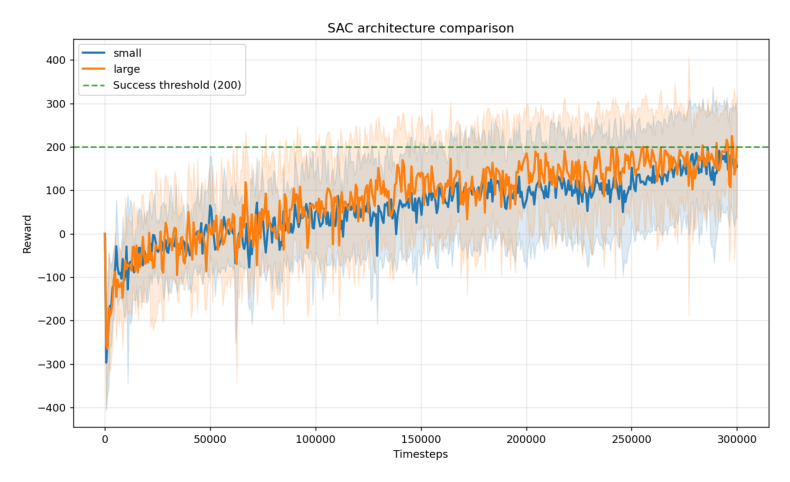

In [3]:
img = mpimg.imread("results/arch_compare/SAC/comparison_curve.png")
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

Z wykresu wynika, że obie architektury (duża i mała) sprawiły się prawie identycznie z lekką przewagą dla modelu dużego, którego krzywa uczenia jest lekko nad tą dla modelu małego, odchylenie standardowe prawie dla całej krzywej jest wyżej. Wyniki doszły wyraźnie do progu 200 - oznacza to poprawne wylądowanie modelu. Niektóre wyniki w pojedynczych próbach osiągają poziom 300 (a piki do 400 punktów), co oznacza "lepsze", bardziej łagodne i poprawne lądowanie, w krótszym czasie.

### Symulacje

Najlepszy model - SAC large - został jeszcze raz nauczony i zapisany do pliku best_model_sac.zip. Następnie wykonano 20 symulacji, podczas których agent wykonywał deterministycznie najlepsze akcje (deterministic=True). Średnią z uzyskanych nagród zaznaczono na wykresie wraz z krzywą uczenia tego modelu.

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[np.float64(312.30651039940585), np.float64(152.541588751817), np.float64(315.13588325772116), np.float64(291.16047359793254), np.float64(300.2570281765427), np.float64(289.86160309378533), np.float64(279.7412538268301), np.float64(308.13549374210106), np.float64(270.66529182309796), np.float64(66.92314707862437), np.float64(277.737705989061), np.float64(246.5926171744812), np.float64(294.02885097989133), np.float64(297.7039672512741), np.float64(299.3967238015808), np.float64(229.68341325700487), np.float64(272.0249984310025), np.float64(263.2691142048117), np.float64(288.10032691709193), np.float64(290.07861609568135)]


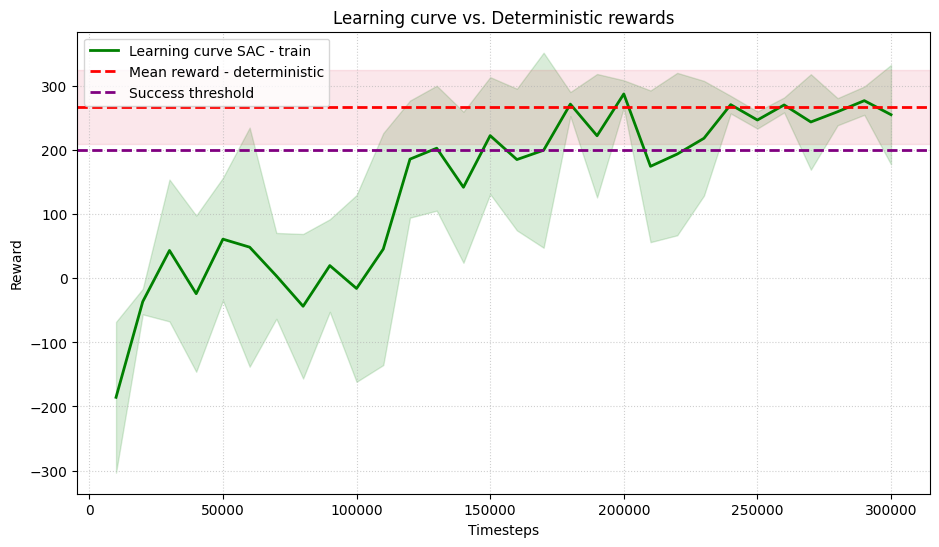

In [24]:
import json
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import SAC


def run_deterministic_simulation_sac(model_path, env_name="LunarLanderContinuous-v3", episodes=10):
    env = gym.make(env_name)

    model = SAC.load(model_path, env=env)

    deterministic_rewards = []
    for episode in range(episodes):
        obs, info = env.reset()
        done = False
        truncated = False
        episode_reward = 0

        while not (done or truncated):
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            episode_reward += reward

        deterministic_rewards.append(episode_reward)

    env.close()
    print(deterministic_rewards)
    return deterministic_rewards


def plot_comparison_sac(json_path, deterministic_rewards):
    with open(json_path, "r") as f:
        learning_data = json.load(f)

    timesteps = learning_data["timesteps"]
    mean_rewards = learning_data["mean"]
    std_rewards = learning_data["std"]
    det_mean = np.mean(deterministic_rewards)
    det_std = np.std(deterministic_rewards)

    plt.figure(figsize=(11, 6))

    plt.plot(
        timesteps,
        mean_rewards,
        label="Learning curve SAC - train",
        color="green",
        linewidth=2,
    )
    plt.fill_between(
        timesteps,
        np.array(mean_rewards) - np.array(std_rewards),
        np.array(mean_rewards) + np.array(std_rewards),
        color="green",
        alpha=0.15,
    )
    plt.axhline(
        y=det_mean,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Mean reward - deterministic",
    )

    plt.axhline(
        y=200,
        color="purple",
        linestyle="--",
        linewidth=2,
        label="Success threshold",
    )
    plt.axhspan(
        det_mean - det_std,
        det_mean + det_std,
        color="crimson",
        alpha=0.1,
    )

    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.legend(loc="upper left")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.title("Learning curve vs. Deterministic rewards")

    plt.show()

ENV_NAME = "LunarLanderContinuous-v3"
MODEL_PATH = "results/best_model_sac/best_model_sac.zip"
JSON_PATH = "results/best_model_sac/curve_sac.json"

rewards = run_deterministic_simulation_sac(
    MODEL_PATH, env_name=ENV_NAME, episodes=20
)

plot_comparison_sac(JSON_PATH, rewards)

Czerwoną kreską zaznaczono średnią nagród zdobytych podczas deterministycznych symulacji. Jest ona wyższa niż próg sukcesu (200). Model nauczył się odpowiednio i działa w warunkach symulacji.